#Install Library

In [141]:
!pip install sastrawi
!pip install transformers
!pip install google-play-scraper

#Import Library

In [142]:
import pandas as pd
from google_play_scraper import reviews, Sort

import nltk
from nltk.corpus import stopwords as nltk_stopwords

from transformers import pipeline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

#Data Collection: Google Playstore



In [143]:
result, continuation_token = reviews(
    'com.apps.MyXL',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=5500)
df_playstore = pd.DataFrame(result)

In [144]:
df_playstore

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,cb7a1be1-529a-44b8-b704-a280189b105a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saluran wa pelanggan hanya dijawab sama AI, ca...",1,0,None,2026-07-10 09:37:22,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-07-10 11:00:19,None
1,5a0e1501-7da8-499e-ae7c-8a969af6ea9d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"selama bertahun tahun gapernah ada kendala, ba...",3,0,8.7.0,2026-07-10 09:31:34,"Hi Kak, Maya akan senang membantu menyelesaika...",2026-07-10 11:00:21,8.7.0
2,8dc5dd4e-1c63-44d9-94c1-69a10cacbaf2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa ya xl kok kuota circle harusnya udah ad...,1,0,9.3.0,2026-07-10 09:07:46,"Hi Kak, Maya mohon maaf ya atas kendalanya, yu...",2025-12-09 03:00:15,9.3.0
3,69df5307-7440-4eb3-a535-5ffd247db7f9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,xl prioritas adalah scam. beli mahal tapi siny...,3,0,9.3.0,2026-07-10 08:57:36,"Hi Kak, mohon maaf atas kendala yang Kakak ala...",2026-07-10 09:00:08,9.3.0
4,55a663aa-b29a-4232-a16d-785ddc4b2dcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,berfungsi sebagai mana mestinya,5,0,9.3.0,2026-07-10 08:49:35,"Hi Kak, terima kasih atas kepercayaannya untuk...",2026-07-10 09:00:10,9.3.0
...,...,...,...,...,...,...,...,...,...,...,...
5495,92467548-4528-4d21-949b-635b65696651,Nana Resmana,https://play-lh.googleusercontent.com/a-/ALV-U...,mantaaf🙏🙏💪💪,5,0,9.2.0,2026-06-03 05:55:01,"Hi Kak, terima kasih atas kepercayaannya untuk...",2026-06-03 07:00:28,9.2.0
5496,fe4f932c-cf8a-4b9b-8a81-45d88af56205,uchiha madarx,https://play-lh.googleusercontent.com/a-/ALV-U...,sinya benerin bukan harga di naikin sinyal uda...,1,0,None,2026-06-03 05:42:29,"Hi Kak, mohon maaf ya kalau ada yang bikin ga ...",2026-06-03 07:00:29,None
5497,8190a9b4-bb5f-4612-b004-4775025175d8,Idham Idham,https://play-lh.googleusercontent.com/a-/ALV-U...,sinyal provider paling jelek sedunia.. sinyal ...,1,0,9.2.0,2026-06-03 05:33:51,"Hi Kak, mohon maaf ya atas kendalanya. Yuk hub...",2026-06-03 07:00:32,9.2.0
5498,6339b025-12b6-4f9d-9c37-b18b7926d8be,Riski Aww,https://play-lh.googleusercontent.com/a/ACg8oc...,"jaringan ngelag tak masuk akal, buka wa aja ga...",1,0,None,2026-06-03 05:23:21,"Hi Kak, mohon maaf ya atas ketidaknyamanan yan...",2026-06-03 07:00:39,None


#Sentiment Analysis

#Read Data

In [145]:
df_playstore.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,cb7a1be1-529a-44b8-b704-a280189b105a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saluran wa pelanggan hanya dijawab sama AI, ca...",1,0,None,2026-07-10 09:37:22,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-07-10 11:00:19,None
1,5a0e1501-7da8-499e-ae7c-8a969af6ea9d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"selama bertahun tahun gapernah ada kendala, ba...",3,0,8.7.0,2026-07-10 09:31:34,"Hi Kak, Maya akan senang membantu menyelesaika...",2026-07-10 11:00:21,8.7.0
2,8dc5dd4e-1c63-44d9-94c1-69a10cacbaf2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa ya xl kok kuota circle harusnya udah ad...,1,0,9.3.0,2026-07-10 09:07:46,"Hi Kak, Maya mohon maaf ya atas kendalanya, yu...",2025-12-09 03:00:15,9.3.0
3,69df5307-7440-4eb3-a535-5ffd247db7f9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,xl prioritas adalah scam. beli mahal tapi siny...,3,0,9.3.0,2026-07-10 08:57:36,"Hi Kak, mohon maaf atas kendala yang Kakak ala...",2026-07-10 09:00:08,9.3.0
4,55a663aa-b29a-4232-a16d-785ddc4b2dcc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,berfungsi sebagai mana mestinya,5,0,9.3.0,2026-07-10 08:49:35,"Hi Kak, terima kasih atas kepercayaannya untuk...",2026-07-10 09:00:10,9.3.0


In [146]:
df = df_playstore[['content']].copy()

##Data Understanding (EDA Awal)

###Cek Missing Value & Duplicate

In [147]:
df.isnull().sum()

,0
content,0


In [148]:
df.duplicated().sum()

np.int64(237)

In [149]:
df.drop_duplicates(inplace=True)

In [150]:
df.duplicated().sum()

np.int64(0)

###Visualisasi

####Distribusi Rating

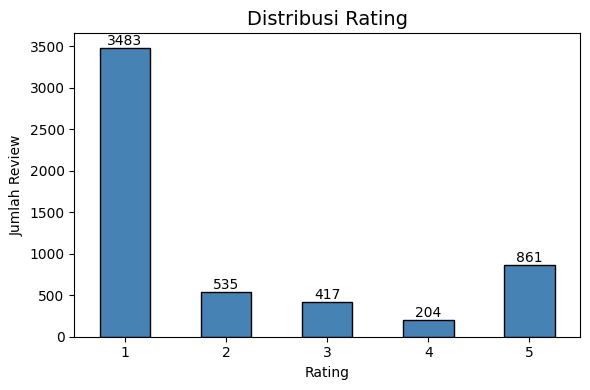

In [151]:
rating = df_playstore['score'].value_counts().sort_index()

plt.figure(figsize=(6,4))
ax = rating.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Distribusi Rating', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)

# Tambahkan jumlah di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

####Distribusi Panjang Review

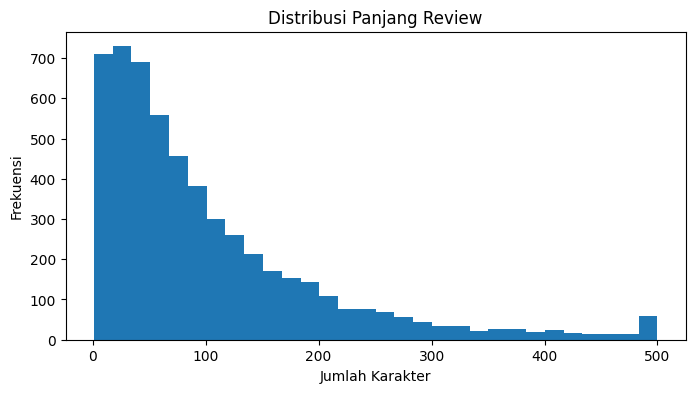

In [152]:
df_playstore['review_length'] = df_playstore['content'].str.len()

plt.figure(figsize=(8,4))
plt.hist(df_playstore['review_length'], bins=30)
plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Karakter')
plt.ylabel('Frekuensi')
plt.show()

####Top 10 Review Terbanyak

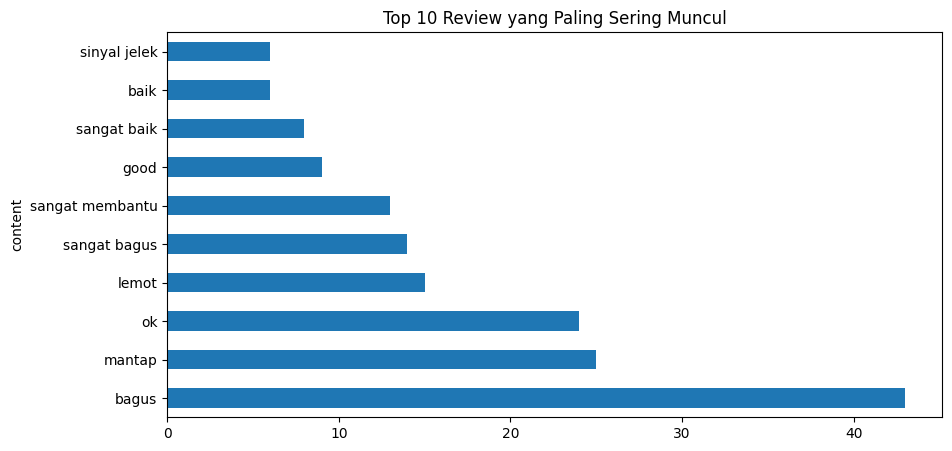

In [153]:
top_review = df_playstore['content'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_review.plot(kind='barh')
plt.title('Top 10 Review yang Paling Sering Muncul')
plt.show()

#Data Preprocessing

##Cleaning

In [154]:
def cleaning(text):
    text = str(text)

    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Hapus mention
    text = re.sub(r'@\w+', ' ', text)

    # Hapus hashtag, tapi pertahankan katanya
    text = re.sub(r'#(\w+)', r'\1', text)

    # Ganti titik dan underscore menjadi spasi
    text = text.replace('.', ' ')
    text = text.replace('_', ' ')

    # Hapus angka
    text = re.sub(r'\d+', ' ', text)

    # Hapus emoji
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        " ",
        text,
        flags=re.UNICODE
    )

    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Sisakan huruf dan spasi
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['cleaning'] = df['content'].apply(cleaning)

In [155]:
df.head()

,content,cleaning
0,"saluran wa pelanggan hanya dijawab sama AI, ca...",saluran wa pelanggan hanya dijawab sama AI cal...
1,"selama bertahun tahun gapernah ada kendala, ba...",selama bertahun tahun gapernah ada kendala bar...
2,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...
3,xl prioritas adalah scam. beli mahal tapi siny...,xl prioritas adalah scam beli mahal tapi sinya...
4,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya


In [156]:
df.tail()

,content,cleaning
5495,mantaaf🙏🙏💪💪,mantaaf
5496,sinya benerin bukan harga di naikin sinyal uda...,sinya benerin bukan harga di naikin sinyal uda...
5497,sinyal provider paling jelek sedunia.. sinyal ...,sinyal provider paling jelek sedunia sinyal ga...
5498,"jaringan ngelag tak masuk akal, buka wa aja ga...",jaringan ngelag tak masuk akal buka wa aja gak...
5499,kenapa XL akir 2 ini jaringan nya jelek banget...,kenapa XL akir ini jaringan nya jelek banget t...


##Case Folding

In [157]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
      return text.lower()
df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(10)

,content,cleaning,case_folding
0,"saluran wa pelanggan hanya dijawab sama AI, ca...",saluran wa pelanggan hanya dijawab sama AI cal...,saluran wa pelanggan hanya dijawab sama ai cal...
1,"selama bertahun tahun gapernah ada kendala, ba...",selama bertahun tahun gapernah ada kendala bar...,selama bertahun tahun gapernah ada kendala bar...
2,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...
3,xl prioritas adalah scam. beli mahal tapi siny...,xl prioritas adalah scam beli mahal tapi sinya...,xl prioritas adalah scam beli mahal tapi sinya...
4,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya
5,aplikasi ini sudah sangat bagus tapi kok saya ...,aplikasi ini sudah sangat bagus tapi kok saya ...,aplikasi ini sudah sangat bagus tapi kok saya ...
6,"registrasinya setengah mati ajg tlol, iya kalo...",registrasinya setengah mati ajg tlol iya kalo ...,registrasinya setengah mati ajg tlol iya kalo ...
7,harga pulsa atau pun kuota sangat mahal dan ti...,harga pulsa atau pun kuota sangat mahal dan ti...,harga pulsa atau pun kuota sangat mahal dan ti...
8,kenapa bonus kuota isi ulang di kuota CIRCLE g...,kenapa bonus kuota isi ulang di kuota CIRCLE g...,kenapa bonus kuota isi ulang di kuota circle g...
9,harga paketan mahal prabayar dan pasca bayar,harga paketan mahal prabayar dan pasca bayar,harga paketan mahal prabayar dan pasca bayar


##Tokenize

In [158]:
def tokenize(text):
    tokens = text.split()
    return tokens
df['tokenize'] = df['case_folding'].apply(tokenize)
df.head()

,content,cleaning,case_folding,tokenize
0,"saluran wa pelanggan hanya dijawab sama AI, ca...",saluran wa pelanggan hanya dijawab sama AI cal...,saluran wa pelanggan hanya dijawab sama ai cal...,"[saluran, wa, pelanggan, hanya, dijawab, sama,..."
1,"selama bertahun tahun gapernah ada kendala, ba...",selama bertahun tahun gapernah ada kendala bar...,selama bertahun tahun gapernah ada kendala bar...,"[selama, bertahun, tahun, gapernah, ada, kenda..."
2,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...,"[kenapa, ya, xl, kok, kuota, circle, harusnya,..."
3,xl prioritas adalah scam. beli mahal tapi siny...,xl prioritas adalah scam beli mahal tapi sinya...,xl prioritas adalah scam beli mahal tapi sinya...,"[xl, prioritas, adalah, scam, beli, mahal, tap..."
4,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya,"[berfungsi, sebagai, mana, mestinya]"


In [159]:
df.tail()

,content,cleaning,case_folding,tokenize
5495,mantaaf🙏🙏💪💪,mantaaf,mantaaf,[mantaaf]
5496,sinya benerin bukan harga di naikin sinyal uda...,sinya benerin bukan harga di naikin sinyal uda...,sinya benerin bukan harga di naikin sinyal uda...,"[sinya, benerin, bukan, harga, di, naikin, sin..."
5497,sinyal provider paling jelek sedunia.. sinyal ...,sinyal provider paling jelek sedunia sinyal ga...,sinyal provider paling jelek sedunia sinyal ga...,"[sinyal, provider, paling, jelek, sedunia, sin..."
5498,"jaringan ngelag tak masuk akal, buka wa aja ga...",jaringan ngelag tak masuk akal buka wa aja gak...,jaringan ngelag tak masuk akal buka wa aja gak...,"[jaringan, ngelag, tak, masuk, akal, buka, wa,..."
5499,kenapa XL akir 2 ini jaringan nya jelek banget...,kenapa XL akir ini jaringan nya jelek banget t...,kenapa xl akir ini jaringan nya jelek banget t...,"[kenapa, xl, akir, ini, jaringan, nya, jelek, ..."


##Normalize Slang

In [203]:
slang_dict = {
    # PARTIKEL & KONJUNGSI
    'yg': 'yang',
    'tp': 'tapi',
    'tpi': 'tapi',
    'jg': 'juga',
    'dg': 'dengan',
    'dgn': 'dengan',
    'sm': 'sama',
    'krn': 'karena',
    'karna': 'karena',
    'dr': 'dari',
    'dri': 'dari',
    'trs': 'terus',
    'trus': 'terus',
    'jd': 'jadi',
    'jdi': 'jadi',
    'bwt': 'buat',
    'utk': 'untuk',
    'blm': 'belum',

    'klu': 'kalau',
    'kalo': 'kalau',
    'klo': 'kalau',
    'kl': 'kalau',
    'kalaw': 'kalau',

    'kyk': 'seperti',
    'kayak': 'seperti',
    'kaya': 'seperti',
    'kek': 'seperti',

    'cm': 'cuma',
    'cmn': 'cuma',
    'cuman': 'cuma',

    'jgn': 'jangan',
    'jngn': 'jangan',

    'gitu': 'begitu',
    'bgtu': 'begitu',
    'gini': 'begini',

    'knp': 'kenapa',
    'ko': 'kok',
    'tak': 'tidak',

    # NEGASI
    'gk': 'tidak',
    'gak': 'tidak',
    'ga': 'tidak',
    'g': 'tidak',
    'nggak': 'tidak',
    'ngga': 'tidak',
    'enggak': 'tidak',
    'tdk': 'tidak',
    'kaga': 'tidak',
    'kagak': 'tidak',
    'ngak': 'tidak',
    'ngk': 'tidak',

    'gada': 'tidak ada',
    'gaada': 'tidak ada',
    'gabisa': 'tidak bisa',
    'gajelas': 'tidak jelas',


    # KATA GANTI ORANG
    'lu': 'kamu',
    'loe': 'kamu',

    'sy': 'saya',
    'sya': 'saya',
    'gw': 'saya',
    'gua': 'saya',
    'gue': 'saya',

    'aq': 'aku',

    'org': 'orang',
    'ank': 'anak',
    'ortu': 'orang tua',
    'mrk': 'mereka',


    # KATA KERJA / BENTUK INFORMAL
    'pake': 'pakai',
    'pke': 'pakai',
    'pkai': 'pakai',
    'pakek': 'pakai',
    'make': 'pakai',
    'dipake': 'dipakai',

    'bgn': 'bangun',

    'dpt': 'dapat',
    'dapet': 'dapat',

    'bkn': 'bukan',

    'bs': 'bisa',
    'bsa': 'bisa',

    'aja': 'saja',
    'ajaa': 'saja',
    'doang': 'saja',

    'liat': 'lihat',
    'kasi': 'kasih',

    'ilang': 'hilang',
    'ngilang': 'hilang',

    'nyesel': 'menyesal',
    'apaan': 'apa',
    'tau': 'tahu',
    'bener': 'benar',
    'benerin': 'perbaiki',
    'nambah': 'tambah',

    'muter': 'berputar',
    'murahin': 'murahkan',
    'adain': 'adakan',


    # KATA SIFAT & KEADAAN
    'baguss': 'bagus',

    'jlek': 'jelek',
    'bapuk': 'jelek',
    'burik': 'buruk',

    'lalot': 'lambat',
    'lelet': 'lambat',
    'lemot': 'lambat',

    'males': 'malas',
    'cepet': 'cepat',

    'tetep': 'tetap',
    'ttp': 'tetap',

    'masi': 'masih',
    'msh': 'masih',

    'sdkt': 'sedikit',
    'dikit': 'sedikit',

    'byk': 'banyak',
    'bnyk': 'banyak',

    'lbh': 'lebih',

    'manisss': 'manis',
    'awallll': 'awal',


    # INTENSIFIER
    'bgd': 'banget',
    'bgt': 'banget',
    'bngt': 'banget',
    'bnget': 'banget',
    'bangett': 'banget',
    'bet': 'banget',
    'bettttt': 'banget',
    'amat': 'banget',


    # SUDAH
    'ud': 'sudah',
    'udh': 'sudah',
    'udah': 'sudah',
    'uda': 'sudah',
    'dah': 'sudah',
    'sdh': 'sudah',


    # LAGI
    'lg': 'lagi',
    'lgy': 'lagi',
    'lgi': 'lagi',


    # WAKTU
    'hr': 'hari',
    'hri': 'hari',
    'thn': 'tahun',
    'bln': 'bulan',

    'skrng': 'sekarang',
    'skrg': 'sekarang',

    'smpe': 'sampai',
    'sampe': 'sampai',

    'ni': 'ini',


    # TEKNIS / PRODUK / JARINGAN
    'abiss': 'habis',
    'abis': 'habis',

    'eror': 'error',

    'aktifa': 'aktif',

    'jaringanx': 'jaringan',
    'jringan': 'jaringan',

    'pitur': 'fitur',

    'lagg': 'lag',
    'ngeleggg': 'lag',
    'ngelag': 'lag',
    'ngeleg': 'lag',

    'kouta': 'kuota',
    'quota': 'kuota',

    'signal': 'sinyal',

    'point': 'poin',

    'rb': 'ribu',

    'abdet': 'update',

    'kepotong': 'terpotong',

    'apk': 'aplikasi',


    # LAIN-LAIN
    'byr': 'bayar',

    'mnrt': 'menurut',
    'pdhl': 'padahal',

    'smoga': 'semoga',
    'moga': 'semoga',

    'gimana': 'bagaimana',

    'yaa': 'ya',
    'yah': 'ya',

    'd': 'di',

    'ad': 'ada',
    'adaaa': 'ada',
    'adaaaaaa': 'ada',

    'tibatiba': 'tiba tiba'
}


def normalize_slang(tokens):
    normalized_tokens = []

    for word in tokens:
        normalized = slang_dict.get(word, word)

        # Memecah hasil normalisasi multi-kata
        # contoh: 'gabisa' -> ['tidak', 'bisa']
        normalized_tokens.extend(normalized.split())

    return normalized_tokens


df['normalize'] = df['tokenize'].apply(normalize_slang)

In [204]:
df.head()

,content,cleaning,case_folding,tokenize,normalize,stopword,stemming,sentiment,sentiment_score
0,"saluran wa pelanggan hanya dijawab sama AI, ca...",saluran wa pelanggan hanya dijawab sama AI cal...,saluran wa pelanggan hanya dijawab sama ai cal...,"[saluran, wa, pelanggan, hanya, dijawab, sama,...","[saluran, wa, pelanggan, hanya, dijawab, sama,...","[saluran, wa, pelanggan, ai, call, center, via...",salur wa langgan ai call center via aplikasi p...,negative,0.922119
1,"selama bertahun tahun gapernah ada kendala, ba...",selama bertahun tahun gapernah ada kendala bar...,selama bertahun tahun gapernah ada kendala bar...,"[selama, bertahun, tahun, gapernah, ada, kenda...","[selama, bertahun, tahun, gapernah, ada, kenda...","[bertahun, gapernah, kendala, kendala, sinyal]",tahun gapernah kendala kendala sinyal,negative,0.829945
2,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...,"[kenapa, ya, xl, kok, kuota, circle, harusnya,...","[kenapa, ya, xl, kok, kuota, circle, harusnya,...","[xl, kuota, circle, kosong, ribu, isii, kuota,...",xl kuota circle kosong ribu isi kuota langsung...,neutral,0.992984
3,xl prioritas adalah scam. beli mahal tapi siny...,xl prioritas adalah scam beli mahal tapi sinya...,xl prioritas adalah scam beli mahal tapi sinya...,"[xl, prioritas, adalah, scam, beli, mahal, tap...","[xl, prioritas, adalah, scam, beli, mahal, tap...","[xl, prioritas, scam, beli, mahal, sinyalnya, ...",xl prioritas scam beli mahal sinyal stabil kot...,negative,0.985897
4,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya,"[berfungsi, sebagai, mana, mestinya]","[berfungsi, sebagai, mana, mestinya]","[berfungsi, mestinya]",fungsi mesti,neutral,0.868895


##Stopword Removal

In [205]:
nltk.download('stopwords', quiet=True)
stopword_id = set(nltk_stopwords.words('indonesian'))

custom_stopwords = {
    'nih', 'btw', 'emang', 'nya', 'ya', 'sih', 'min', 'admin', 'mah', 'pa',
    'deh', 'tuh', 'loh', 'kak', 'iya',
    'lho', 'bos', 'gan', 'hehe', 'haha', 'hehehe'
}

stopword_id.update(custom_stopwords)

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopword_id]
df['stopword'] = df['normalize'].apply(remove_stopwords)

In [206]:
df.head()

,content,cleaning,case_folding,tokenize,normalize,stopword,stemming,sentiment,sentiment_score
0,"saluran wa pelanggan hanya dijawab sama AI, ca...",saluran wa pelanggan hanya dijawab sama AI cal...,saluran wa pelanggan hanya dijawab sama ai cal...,"[saluran, wa, pelanggan, hanya, dijawab, sama,...","[saluran, wa, pelanggan, hanya, dijawab, sama,...","[saluran, wa, pelanggan, ai, call, center, via...",salur wa langgan ai call center via aplikasi p...,negative,0.922119
1,"selama bertahun tahun gapernah ada kendala, ba...",selama bertahun tahun gapernah ada kendala bar...,selama bertahun tahun gapernah ada kendala bar...,"[selama, bertahun, tahun, gapernah, ada, kenda...","[selama, bertahun, tahun, gapernah, ada, kenda...","[bertahun, gapernah, kendala, kendala, sinyal]",tahun gapernah kendala kendala sinyal,negative,0.829945
2,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...,kenapa ya xl kok kuota circle harusnya udah ad...,"[kenapa, ya, xl, kok, kuota, circle, harusnya,...","[kenapa, ya, xl, kok, kuota, circle, harusnya,...","[xl, kuota, circle, kosong, ribu, isii, kuota,...",xl kuota circle kosong ribu isi kuota langsung...,neutral,0.992984
3,xl prioritas adalah scam. beli mahal tapi siny...,xl prioritas adalah scam beli mahal tapi sinya...,xl prioritas adalah scam beli mahal tapi sinya...,"[xl, prioritas, adalah, scam, beli, mahal, tap...","[xl, prioritas, adalah, scam, beli, mahal, tap...","[xl, prioritas, scam, beli, mahal, sinyalnya, ...",xl prioritas scam beli mahal sinyal stabil kot...,negative,0.985897
4,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya,berfungsi sebagai mana mestinya,"[berfungsi, sebagai, mana, mestinya]","[berfungsi, sebagai, mana, mestinya]","[berfungsi, mestinya]",fungsi mesti,neutral,0.868895


###Stemming

In [207]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stemming(tokens):
  kalimat = ' '.join(tokens)
  return stemmer.stem(kalimat)
df['stemming'] = df['stopword'].apply(stemming)

#Sentiment Labeling

In [208]:
classifier = pipeline(
    "sentiment-analysis",
    model = "w11wo/indonesian-roberta-base-sentiment-classifier")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [209]:
labels = []
scores = []

for text in df['stemming']:

    if pd.notnull(text):

        result = classifier(str(text))[0]

        labels.append(result['label'])
        scores.append(result['score'])

    else:

        labels.append('unknown')
        scores.append(0)

df['sentiment'] = labels
df['sentiment_score'] = scores

In [210]:
df[['stemming','sentiment','sentiment_score']].head(20)

,stemming,sentiment,sentiment_score
0,salur wa langgan ai call center via aplikasi p...,negative,0.922119
1,tahun gapernah kendala kendala sinyal,negative,0.829945
2,xl kuota circle kosong ribu isi kuota langsung...,neutral,0.992984
3,xl prioritas scam beli mahal sinyal stabil kot...,negative,0.985897
4,fungsi mesti,neutral,0.868895
5,aplikasi bagus isi kuota bonus balikin xl circ...,positive,0.646188
6,registrasi mati ajg tlol jaring bagus gblk nia...,negative,0.981993
7,harga pulsa kuota mahal rekomen sinya buruk,negative,0.998526
8,bonus kuota isi ulang kuota circle lagimengece...,negative,0.946309
9,harga paket mahal prabayar pasca bayar,neutral,0.904134


In [211]:
df['sentiment'].value_counts()

,count
sentiment,
negative,3321
neutral,1512
positive,430


#EDA

##1. Distribusi Sentimen

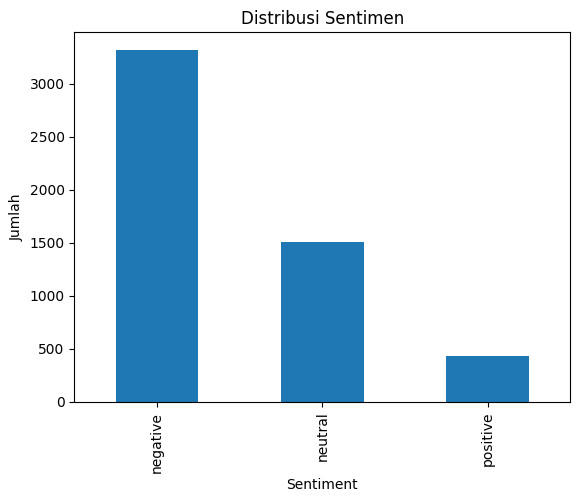

In [212]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(
    kind='bar',
    xlabel='Sentiment',
    ylabel='Jumlah',
    title='Distribusi Sentimen'
)

plt.show()

<Axes: ylabel='count'>

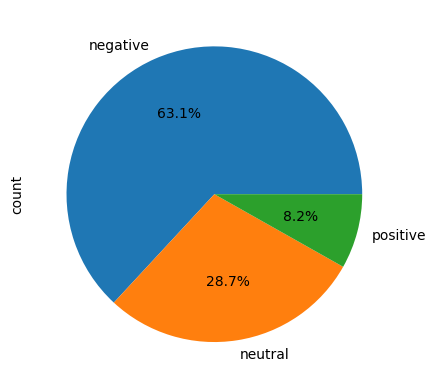

In [213]:
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

##2. WordCloud Positive

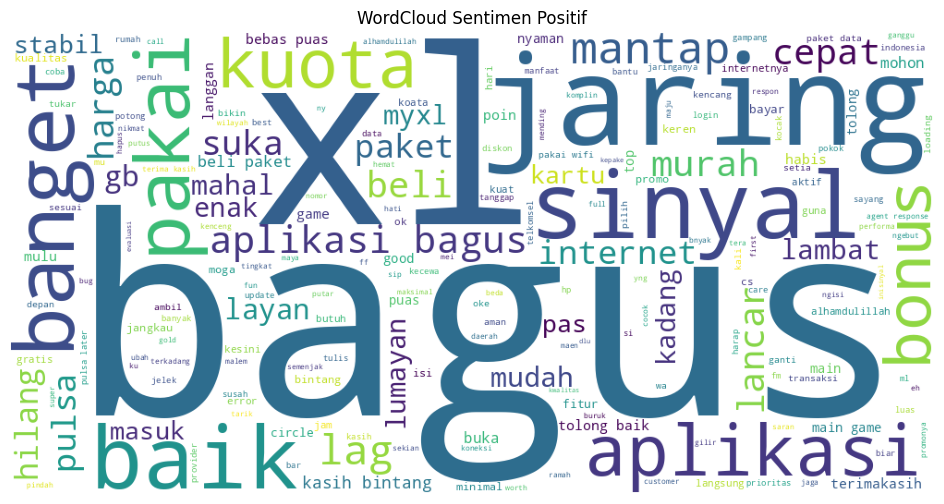

In [214]:
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['sentiment']=="positive"]['stemming']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Sentimen Positif")
plt.show()

##3. WordCloud Negative

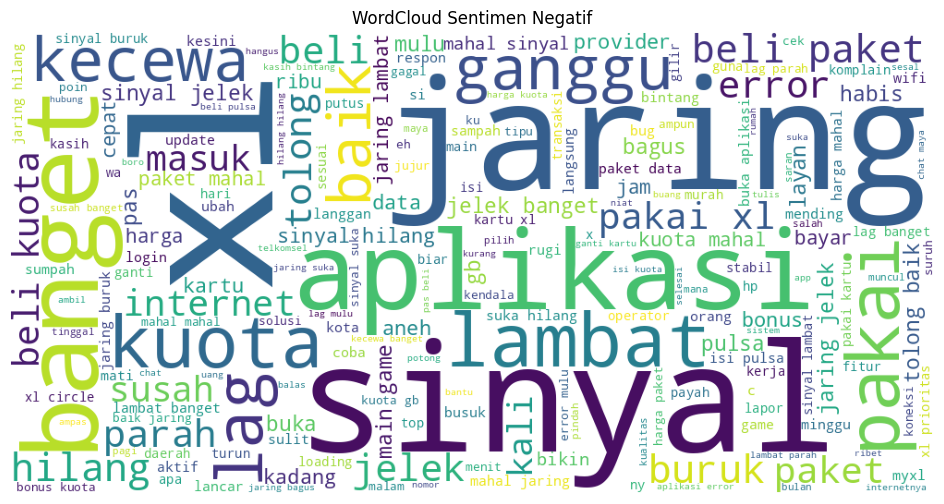

In [215]:
negative_text = " ".join(
    df[df['sentiment']=="negative"]['stemming']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Sentimen Negatif")
plt.show()

##4. Top Frequent Words

In [216]:
from collections import Counter

words = ' '.join(df['stemming']).split()

Counter(words).most_common(20)

[('xl', 2024),
 ('jaring', 1456),
 ('sinyal', 1363),
 ('kuota', 1183),
 ('paket', 1007),
 ('beli', 984),
 ('aplikasi', 970),
 ('pakai', 869),
 ('banget', 865),
 ('hilang', 666),
 ('lambat', 653),
 ('baik', 627),
 ('jelek', 569),
 ('mahal', 537),
 ('pulsa', 536),
 ('lag', 527),
 ('tolong', 524),
 ('gb', 395),
 ('bagus', 381),
 ('bonus', 348)]

In [217]:
import pandas as pd

freq = pd.DataFrame(
    Counter(words).most_common(20),
    columns=['word','count']
)

<Axes: xlabel='word'>

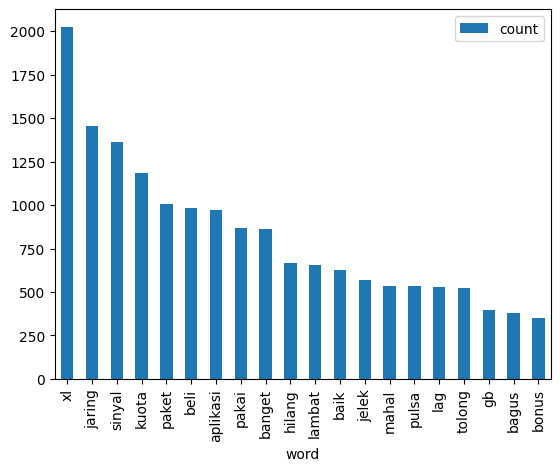

In [218]:
freq.plot.bar(
    x='word',
    y='count'
)

##5. Bigram

In [219]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    ngram_range=(2,2)
)

In [220]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(2,2))

X = cv.fit_transform(df['stemming'])

In [221]:
bigrams = cv.get_feature_names_out()

In [222]:
counts = X.sum(axis=0).A1

In [223]:
import pandas as pd

bigram_df = pd.DataFrame({
    'Bigram': bigrams,
    'Frequency': counts
})

bigram_df = bigram_df.sort_values(by='Frequency', ascending=False)

bigram_df.head(20)

,Bigram,Frequency
3075,beli paket,335
3039,beli kuota,246
18577,pakai xl,211
24594,tolong baik,204
16836,my xl,165
24750,top up,155
22470,sinyal jelek,140
14989,main game,137
18653,paket data,132
10533,jelek banget,128


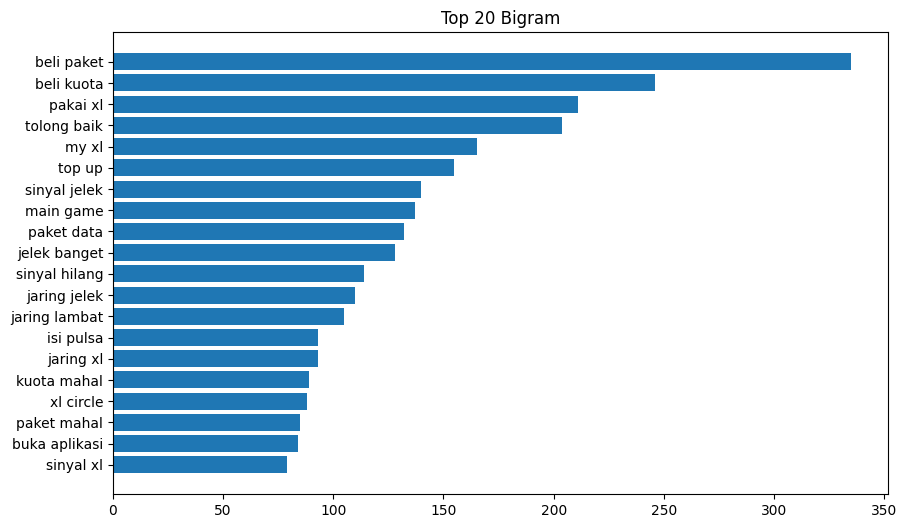

In [224]:
import matplotlib.pyplot as plt

top20 = bigram_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20['Bigram'], top20['Frequency'])
plt.gca().invert_yaxis()
plt.title("Top 20 Bigram")
plt.show()

#Feature Engineering

##Split Data

In [225]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    df['stemming'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)


##TF-IDF

In [245]:
df['stemming'].head()

,stemming
0,salur wa langgan ai call center via aplikasi p...
1,tahun gapernah kendala kendala sinyal
2,xl kuota circle kosong ribu isi kuota langsung...
3,xl prioritas scam beli mahal sinyal stabil kot...
4,fungsi mesti


In [227]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # unigram + bigram
)

# Transformasi data teks menjadi fitur numerik
# X = tfidf.fit_transform(df['stemming'])

# Feature Engineering
X_train = tfidf.fit_transform(train_data)
X_test = tfidf.transform(test_data)

# Cek hasil
print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print(tfidf.get_feature_names_out()[:20])

Shape X_train: (4210, 5000)
Shape X_test : (1053, 5000)
['aamiin' 'abai' 'abal' 'acara' 'account' 'ada' 'adad' 'adahilang'
 'adakan' 'adakan bonus' 'adakan paket' 'add' 'add on' 'adu' 'aduh' 'afk'
 'agen' 'agent' 'ah' 'ai']


#Modeling

##Naive Bayes

In [228]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Naive Bayes
naive_bayes = MultinomialNB()

# Training model
naive_bayes.fit(X_train, train_labels)

# Prediksi data testing
pred_nb = naive_bayes.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_nb)
report = classification_report(test_labels, pred_nb)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

# Confusion Matrix
labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(
    test_labels,
    pred_nb,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {label}' for label in labels],
    columns=[f'Predicted {label}' for label in labels]
)

print('\nConfusion Matrix - Naive Bayes:')
display(cm_df)

Accuracy: 0.6838

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.95      0.80       664
     neutral       0.65      0.29      0.40       303
    positive       1.00      0.05      0.09        86

    accuracy                           0.68      1053
   macro avg       0.78      0.43      0.43      1053
weighted avg       0.70      0.68      0.62      1053


Confusion Matrix - Naive Bayes:


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,629,35,0
Actual neutral,216,87,0
Actual positive,71,11,4


##Decision Tree

In [229]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)

# Training model
decision_tree.fit(X_train, train_labels)

# Prediksi data testing
pred_dt = decision_tree.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_dt)
report = classification_report(test_labels, pred_dt)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

# Confusion Matrix
labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(
    test_labels,
    pred_dt,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {label}' for label in labels],
    columns=[f'Predicted {label}' for label in labels]
)

print('\nConfusion Matrix - Decision Tree:')
display(cm_df)

Accuracy: 0.7189

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.77      0.79       664
     neutral       0.61      0.67      0.64       303
    positive       0.46      0.47      0.46        86

    accuracy                           0.72      1053
   macro avg       0.63      0.64      0.63      1053
weighted avg       0.73      0.72      0.72      1053


Confusion Matrix - Decision Tree:


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,513,118,33
Actual neutral,85,204,14
Actual positive,34,12,40


##Random Forest

In [230]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Random Forest
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training model
random_forest.fit(X_train, train_labels)

# Prediksi data testing
pred_rf = random_forest.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_rf)
report = classification_report(test_labels, pred_rf)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

# Confusion Matrix
labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(
    test_labels,
    pred_rf,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {label}' for label in labels],
    columns=[f'Predicted {label}' for label in labels]
)

print('\nConfusion Matrix - Random Forest:')
display(cm_df)

Accuracy: 0.7692

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.88      0.84       664
     neutral       0.67      0.64      0.66       303
    positive       0.84      0.37      0.52        86

    accuracy                           0.77      1053
   macro avg       0.77      0.63      0.67      1053
weighted avg       0.77      0.77      0.76      1053


Confusion Matrix - Random Forest:


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,583,78,3
Actual neutral,105,195,3
Actual positive,37,17,32


##AdaBoost

In [231]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model AdaBoost
adaboost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

# Training model
adaboost.fit(X_train, train_labels)

# Prediksi data testing
pred_adb = adaboost.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_adb)
report = classification_report(test_labels, pred_adb)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

# Confusion Matrix
labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(
    test_labels,
    pred_adb,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {label}' for label in labels],
    columns=[f'Predicted {label}' for label in labels]
)

print('\nConfusion Matrix - AdaBoost:')
display(cm_df)

Accuracy: 0.6581

Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.96      0.78       664
     neutral       0.55      0.12      0.20       303
    positive       0.75      0.24      0.37        86

    accuracy                           0.66      1053
   macro avg       0.66      0.44      0.45      1053
weighted avg       0.64      0.66      0.58      1053


Confusion Matrix - AdaBoost:


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,636,22,6
Actual neutral,266,36,1
Actual positive,58,7,21


##Logistic Regression

In [232]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

# Inisialisasi model Logistic Regression
logistic_regression = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Training model
logistic_regression.fit(X_train, train_labels)

# Prediksi data testing
pred_lr = logistic_regression.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_lr)
report = classification_report(test_labels, pred_lr)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')

print('Classification Report:')
print(report)


# Confusion Matrix
labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(
    test_labels,
    pred_lr,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {label}' for label in labels],
    columns=[f'Predicted {label}' for label in labels]
)

print('\nConfusion Matrix - Logistic Regression:')
display(cm_df)

Accuracy: 0.7730

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.90      0.84       664
     neutral       0.72      0.61      0.66       303
    positive       0.78      0.33      0.46        86

    accuracy                           0.77      1053
   macro avg       0.76      0.61      0.65      1053
weighted avg       0.77      0.77      0.76      1053


Confusion Matrix - Logistic Regression:


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,600,59,5
Actual neutral,114,186,3
Actual positive,43,15,28


##Support Vector Machine (SVM)  

In [233]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model Support Vector Machine
svm = LinearSVC(random_state=42)

# Training model
svm.fit(X_train, train_labels)

# Prediksi data testing
pred_svm = svm.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(test_labels, pred_svm)
report = classification_report(test_labels, pred_svm)

# Menampilkan hasil evaluasi
print(f'Accuracy: {accuracy:.4f}\n')
print('Classification Report:')
print(report)

# Confusion Matrix
labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(
    test_labels,
    pred_svm,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual {label}' for label in labels],
    columns=[f'Predicted {label}' for label in labels]
)

print('\nConfusion Matrix - SVM:')
display(cm_df)

Accuracy: 0.7759

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.87      0.84       664
     neutral       0.69      0.64      0.67       303
    positive       0.69      0.49      0.57        86

    accuracy                           0.78      1053
   macro avg       0.73      0.67      0.69      1053
weighted avg       0.77      0.78      0.77      1053


Confusion Matrix - SVM:


,Predicted negative,Predicted neutral,Predicted positive
Actual negative,580,73,11
Actual neutral,100,195,8
Actual positive,29,15,42


#Model Evaluation

In [234]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [235]:
hasil = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Decision Tree',
        'Random Forest',
        'AdaBoost',
        'Logistic Regression',
        'SVM'
    ],

    'Accuracy': [
        accuracy_score(test_labels, pred_nb),
        accuracy_score(test_labels, pred_dt),
        accuracy_score(test_labels, pred_rf),
        accuracy_score(test_labels, pred_adb),
        accuracy_score(test_labels, pred_lr),
        accuracy_score(test_labels, pred_svm)
    ],

    'Precision': [
        precision_recall_fscore_support(
            test_labels, pred_nb, average='macro'
        )[0],

        precision_recall_fscore_support(
            test_labels, pred_dt, average='macro'
        )[0],

        precision_recall_fscore_support(
            test_labels, pred_rf, average='macro'
        )[0],

        precision_recall_fscore_support(
            test_labels, pred_adb, average='macro'
        )[0],

        precision_recall_fscore_support(
            test_labels, pred_lr, average='macro'
        )[0],

        precision_recall_fscore_support(
            test_labels, pred_svm, average='macro'
        )[0]
    ],

    'Recall': [
        precision_recall_fscore_support(
            test_labels, pred_nb, average='macro'
        )[1],

        precision_recall_fscore_support(
            test_labels, pred_dt, average='macro'
        )[1],

        precision_recall_fscore_support(
            test_labels, pred_rf, average='macro'
        )[1],

        precision_recall_fscore_support(
            test_labels, pred_adb, average='macro'
        )[1],

        precision_recall_fscore_support(
            test_labels, pred_lr, average='macro'
        )[1],

        precision_recall_fscore_support(
            test_labels, pred_svm, average='macro'
        )[1]
    ],

    'F1-Score': [
        precision_recall_fscore_support(
            test_labels, pred_nb, average='macro'
        )[2],

        precision_recall_fscore_support(
            test_labels, pred_dt, average='macro'
        )[2],

        precision_recall_fscore_support(
            test_labels, pred_rf, average='macro'
        )[2],

        precision_recall_fscore_support(
            test_labels, pred_adb, average='macro'
        )[2],

        precision_recall_fscore_support(
            test_labels, pred_lr, average='macro'
        )[2],

        precision_recall_fscore_support(
            test_labels, pred_svm, average='macro'
        )[2]
    ]
})


# Urutkan berdasarkan F1-Score tertinggi
hasil = hasil.sort_values(
    by='F1-Score',
    ascending=False
)

hasil.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
5,SVM,0.7759,0.7319,0.6685,0.6939
2,Random Forest,0.7692,0.7729,0.6312,0.6711
4,Logistic Regression,0.7730,0.7619,0.6144,0.6547
1,Decision Tree,0.7189,0.6274,0.6370,0.6315
3,AdaBoost,0.6581,0.6554,0.4403,0.4491
0,Naive Bayes,0.6838,0.7803,0.4270,0.4281


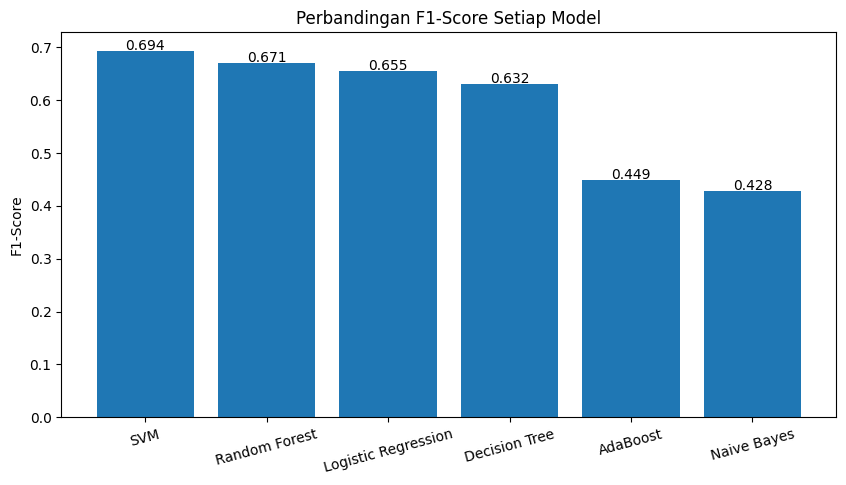

In [236]:
plt.figure(figsize=(10,5))

plt.bar(hasil['Model'], hasil['F1-Score'])

plt.title("Perbandingan F1-Score Setiap Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)

for i, v in enumerate(hasil['F1-Score']):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()

F1-Score digunakan sebagai acuan pemilihan model terbaik karena dataset memiliki distribusi kelas yang tidak seimbang, sehingga setiap kelas memperoleh bobot evaluasi yang sama.

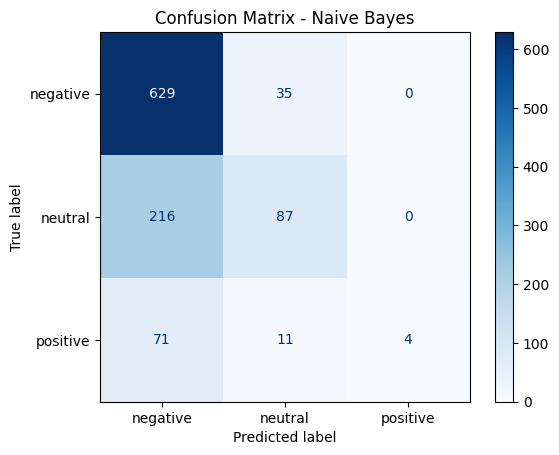

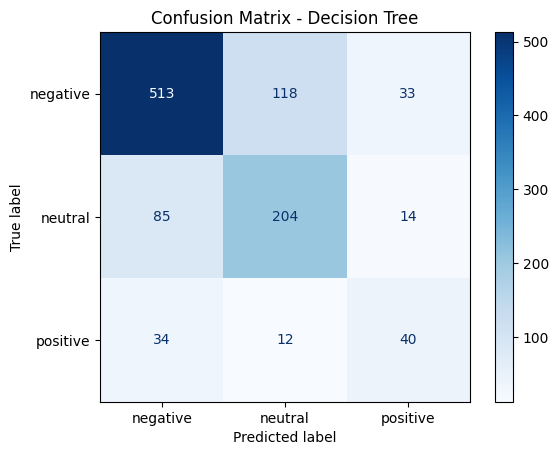

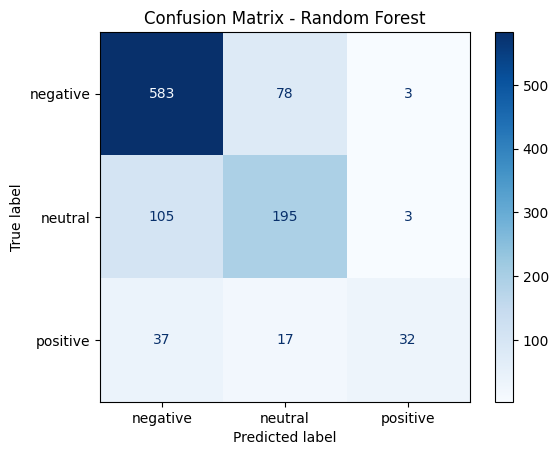

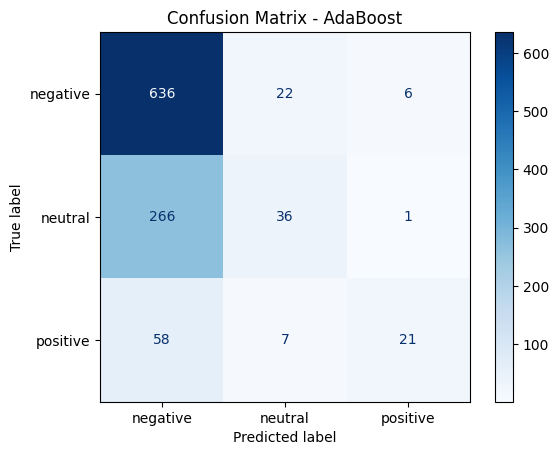

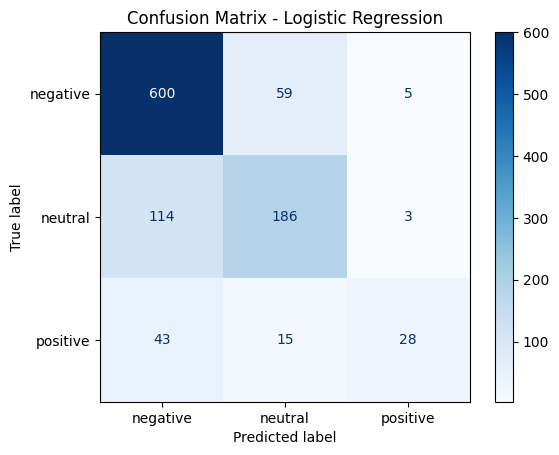

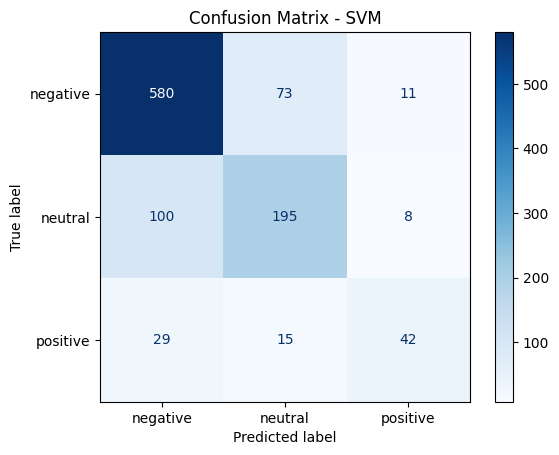

In [237]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = {
    'Naive Bayes': pred_nb,
    'Decision Tree': pred_dt,
    'Random Forest': pred_rf,
    'AdaBoost': pred_adb,
    'Logistic Regression': pred_lr,
    'SVM': pred_svm
}

for name, pred in predictions.items():

    ConfusionMatrixDisplay.from_predictions(
        test_labels,
        pred,
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.show()

In [238]:
#cek tipe
print(type(svm))
print(svm)

<class 'sklearn.svm._classes.LinearSVC'>
LinearSVC(random_state=42)


##Probability Calibration

LinearSVC tidak menghasilkan probabilitas secara langsung. Oleh karena itu dilakukan kalibrasi menggunakan metode sigmoid agar model dapat menghasilkan confidence score pada tahap deployment.

##Calibrated LinearSVC

In [239]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

# Model dasar LinearSVC
base_svm = LinearSVC(random_state=42)

# Kalibrasi probabilitas dengan cross-validation
calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method='sigmoid',
    cv=5
)

# Training model terkalibrasi
calibrated_svm.fit(X_train, train_labels)

CalibratedClassifierCV(cv=5, estimator=LinearSVC(random_state=42))

##Evaluation After Calibration

Model hasil kalibrasi dievaluasi kembali untuk memastikan performa tetap baik sebelum digunakan pada proses deployment.

Accuracy Calibrated SVM: 0.7721

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.88      0.84       664
     neutral       0.70      0.63      0.66       303
    positive       0.69      0.44      0.54        86

    accuracy                           0.77      1053
   macro avg       0.73      0.65      0.68      1053
weighted avg       0.77      0.77      0.77      1053



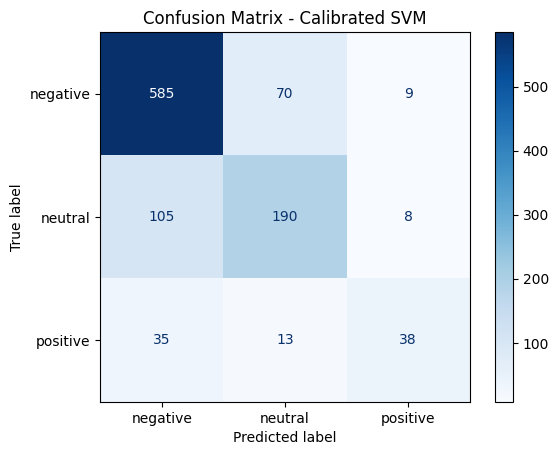

In [240]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Prediksi menggunakan Calibrated SVM
pred_calibrated = calibrated_svm.predict(X_test)

# Accuracy
accuracy_calibrated = accuracy_score(
    test_labels,
    pred_calibrated
)

print(f"Accuracy Calibrated SVM: {accuracy_calibrated:.4f}\n")

# Precision, Recall, F1-Score, dan Support
print("Classification Report:")
print(
    classification_report(
        test_labels,
        pred_calibrated
    )
)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    calibrated_svm,
    X_test,
    test_labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Calibrated SVM")
plt.show()

##Probability Check

Memastikan model hasil kalibrasi dapat menghasilkan nilai probabilitas (confidence score) untuk setiap kelas sentimen sebelum digunakan pada tahap deployment.

In [241]:
# Cek probabilitas hasil kalibrasi
probabilities = calibrated_svm.predict_proba(X_test[:5])

print("Classes:")
print(calibrated_svm.classes_)

print("\nProbabilities:")
print(probabilities)

Classes:
['negative' 'neutral' 'positive']

Probabilities:
[[0.49505744 0.00446591 0.50047665]
 [0.86230079 0.10985321 0.027846  ]
 [0.09394585 0.20229144 0.70376271]
 [0.08515939 0.85690327 0.05793734]
 [0.16452104 0.51531245 0.32016651]]


In [242]:
import numpy as np

# Contoh prediksi pada data baru
komentar = [
    "Sinyal kenceng mantep stabil, top banget jempol 4!!",
    "Sinyalnya sering hilang dan internet sangat lambat",
    "Aplikasinya normal aja sih bukan yang gimana gimana",
    "Kecewa parah, kuota cepat habis dan jaringan sering putus"
]

# Ubah menjadi fitur TF-IDF
komentar_tfidf = tfidf.transform(komentar)

# Prediksi sentimen
prediksi = calibrated_svm.predict(komentar_tfidf)

# Confidence score
probabilitas = calibrated_svm.predict_proba(komentar_tfidf)

# Tampilkan hasil
for komentar, label, prob in zip(komentar, prediksi, probabilitas):
    confidence = np.max(prob)

    print(f"Komentar   : {komentar}")
    print(f"Prediksi   : {label}")
    print(f"Confidence : {confidence:.2%}")
    print("-" * 60)

Komentar   : Sinyal kenceng mantep stabil, top banget jempol 4!!
Prediksi   : positive
Confidence : 59.38%
------------------------------------------------------------
Komentar   : Sinyalnya sering hilang dan internet sangat lambat
Prediksi   : negative
Confidence : 96.73%
------------------------------------------------------------
Komentar   : Aplikasinya normal aja sih bukan yang gimana gimana
Prediksi   : neutral
Confidence : 78.74%
------------------------------------------------------------
Komentar   : Kecewa parah, kuota cepat habis dan jaringan sering putus
Prediksi   : negative
Confidence : 96.99%
------------------------------------------------------------


#Deploy

In [243]:
import joblib

# Simpan model SVM yang sudah dikalibrasi
joblib.dump(
    calibrated_svm,
    'svm_calibrated_model.pkl'
)

# Simpan TF-IDF Vectorizer
joblib.dump(
    tfidf,
    'tfidf.pkl'
)

print("Model dan TF-IDF berhasil disimpan.")

Model dan TF-IDF berhasil disimpan.


In [244]:
import os

print(os.listdir())

['.config', 'myxl_slang_analysis.csv', 'svm_calibrated_model.pkl', 'tfidf.pkl', 'sample_data']
